<a href="https://colab.research.google.com/github/TienNguyen0712/ai-engineer-journey/blob/main/chapter3_pytorch_computer_vision/flower_classification_cnn_tranfers_learning/00_data_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 **Xây dựng, so sánh mạng CNN với các phương pháp Transfer Learning trong việc phân loại ảnh**

## ⚡**Giới thiệu**

### **Các khái niệm cơ bản**

- **Transfer Learning:** Là một kỹ thuật trong AI và học máy, nơi một mô hình đã học từ một nhiệm vụ trước đó được "tái sử dụng" để giải quyết nhiệm vụ mới nhanh hơn và hiệu quả hơn *(Ví dụ một mô hình đã được huấn luyện để nhận diện các bức ảnh chó mèo, xe cộ -> Sau đó dạy nó thực hiện nhận diện bệnh trên lá cây -> Thay vì huấn luyện từ đầu ta sẽ lấy mô hình cũ rồi "fine-tune" thêm dữ liệu lá cây)*

- **Convolutional Neural Network (CNN):** Là một loại mạng nơ-ron học sâu được thiết kế dặc biệt để xử lý dữ liệu dạng ảnh, CNN rất mạnh trong các bài toán phân loại ảnh, nhận diện khuôn mặt, phát hiện vật thể, OCR, xe tự lái, ...

### **Giới thiệu bộ dữ liệu**

Bộ dữ liệu liệu Flowers Recognition gán nhãn của 4242 hình ảnh về các loại hoa khác nhau, dữ liệu được thu thập dự vào các trang data flicr, google, yandex
- Các bức ảnh dược chia thành 5 nhóm:
  - `daisy`: hoa cúc
  - `tulip`: hoa tulip
  - `rose`: hoa hồng
  - `sunflower`: hoa hướng dương
  - `dandelion`: hoa bồ công anh

Với mỗi lớp có khoảng 800 ảnh: Kích thước ảnh **320px x 240px**

[Liên kết bộ dữ liệu](https://www.kaggle.com/datasets/alxmamaev/flowers-recognition)

### **Đầu ra mong muốn**

Sau notebook này:
- Dữ liệu sẽ được chuẩn hóa và sẵn sàng cho huấn luyện
- Pipeline preprocessing sẽ được xây dựng hoàn chỉnh
- Dataset có thể được sử dụng cho:
  - CNN Baseline
  - Transfer Learning
  - Fine-tuning pretrained models

In [2]:
!mkdir -p ~/.kaggle # Tạo thư mục kaggle
!cp kaggle.json ~/.kaggle/ # Copy json
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d alxmamaev/flowers-recognition # Tải dataset

Dataset URL: https://www.kaggle.com/datasets/alxmamaev/flowers-recognition
License(s): unknown
100% 225M/225M [00:00<00:00, 241MB/s]



In [20]:
# !unzip flowers-recognition.zip # Giải nén dữ liệu. Khi chạy notebook mở comment

In [5]:
import os
os.listdir("flowers") # Kiểm tra dữ liệu

['daisy', 'rose', 'sunflower', 'dandelion', 'tulip']

In [6]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.data import random_split
from PIL import Image

## 📚 **Đọc dữ liệu và khám phá dữ liệu**

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)), # Chuyển size các hình thành 224 x 224
    transforms.ToTensor(), # Đôi size hình thành tensor
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

dataset = datasets.ImageFolder(
    "flowers",
    transform=transform
)

print("\nClass Mapping:")
print(dataset.class_to_idx) # Mapping các nhãn với một con số index


Class Mapping:
{'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


In [8]:
print("\nTotal Images:") # Xuất ra tổng số hình có trong dữ liệu
print(len(dataset))


Total Images:
4317


In [9]:
loader = DataLoader(
    dataset,
    batch_size=32, # Dựng Loader
    shuffle=True
)

In [10]:
images, labels = next(iter(loader))

print("\nBatch Shape:")
print(images.shape)

print("\nLabels Shape:")
print(labels.shape)


Batch Shape:
torch.Size([32, 3, 224, 224])

Labels Shape:
torch.Size([32])


### **Trực quan hóa hình ảnh**


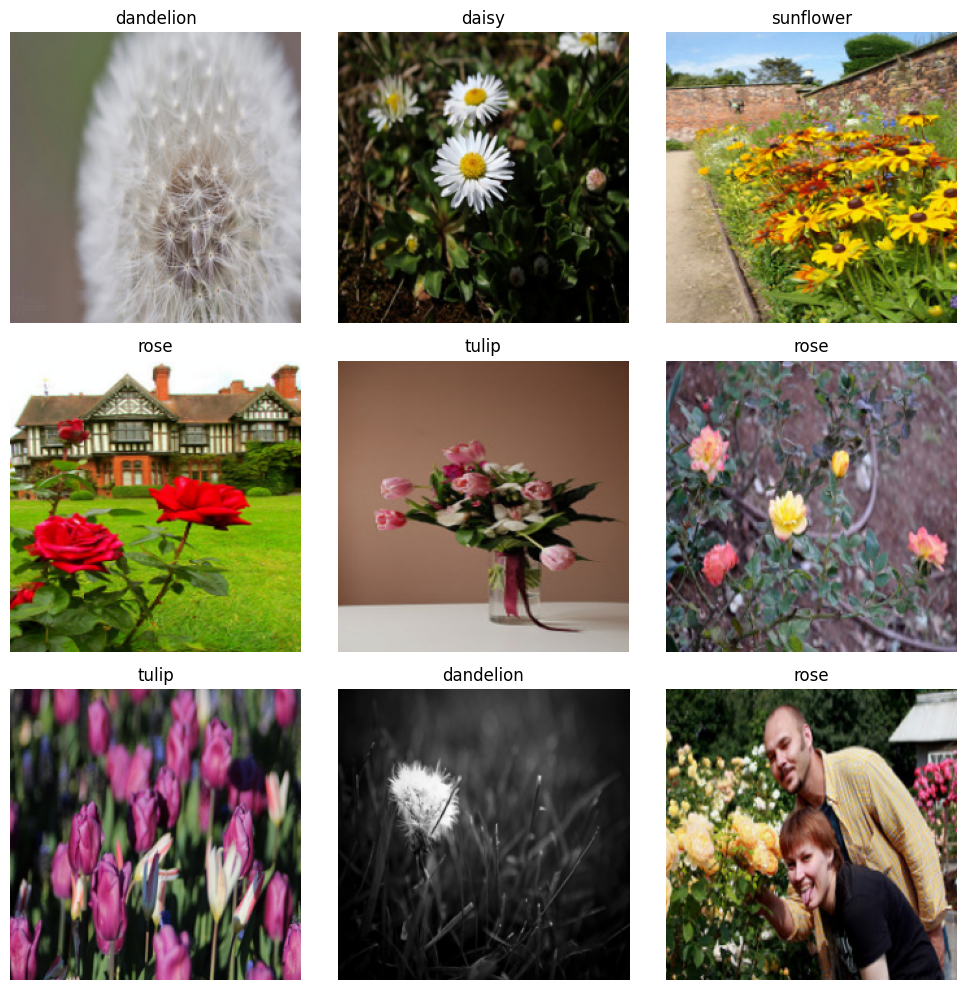

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    image = images[i].permute(1, 2, 0).numpy()
    # Unnormalize image
    image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    image = image.clip(0, 1)
    ax.imshow(image)
    ax.set_title(dataset.classes[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

### **Tương tác với dữ liệu**

Data augmentation được áp dụng nhằm tăng tính đa dạng của dữ liệu huấn luyện và giảm hiện tượng overfitting.

Các kỹ thuật augmentation bao gồm:
- Horizontal Flip
- Random Rotation
- Random Affine
- Random Crop
- Color Jitter


In [13]:
# Thêm augmentation vào transform
train_transform = transforms.Compose([

    transforms.Resize((224, 224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(20),

    transforms.RandomAffine(
        degrees=0,
        translate=(0.1, 0.1)
    ),

    transforms.RandomResizedCrop(
        224,
        scale=(0.8, 1.0)
    ),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )


])

In [14]:
# tạo dataset mới

train_dataset = datasets.ImageFolder(
    root="flowers",
    transform=train_transform
)

In [15]:
# Tạo bộ loader mới
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

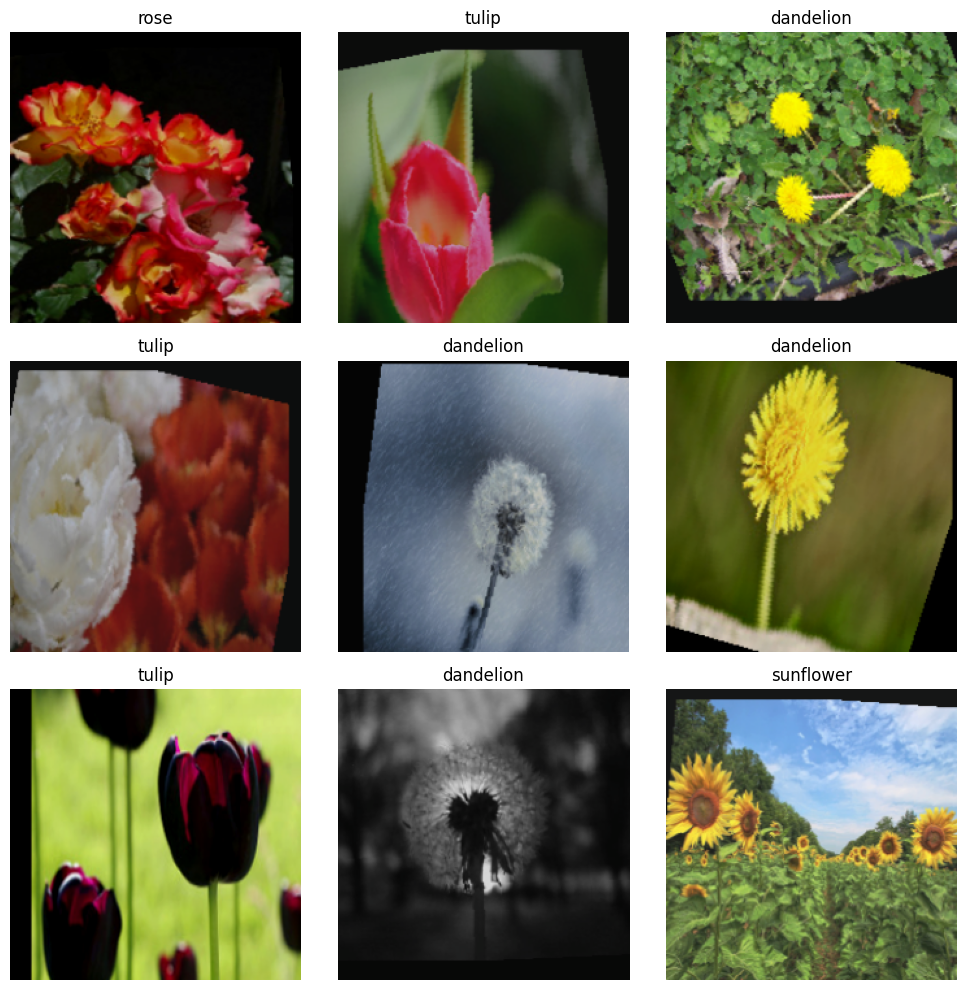

In [16]:
# Xuất hình
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(3, 3, figsize=(10,10))

for i, ax in enumerate(axes.flat):

    image = images[i].permute(1,2,0).numpy()

    # Unnormalize
    image = image * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]

    image = image.clip(0,1)

    ax.imshow(image)

    ax.set_title(train_dataset.classes[labels[i]])

    ax.axis("off")

plt.tight_layout()
plt.show()

## 🧪 **Chia dữ liệu thành các tập train/validation**


In [17]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_data, val_data = random_split(
    train_dataset,
    [train_size, val_size]
)

In [18]:
train_loader = DataLoader(
    train_data,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_data,
    batch_size=32,
    shuffle=False
)

In [19]:
print("Train size:", len(train_data))
print("Validation size:", len(val_data))

Train size: 3453
Validation size: 864


## **Tóm tắt**

Trong notebook này, dataset Flowers Recognition đã được khám phá và tiền xử lý nhằm chuẩn bị cho quá trình huấn luyện mô hình Deep Learning.

Các bước chính đã thực hiện bao gồm:

- Đọc và kiểm tra cấu trúc dataset
- Hiển thị ảnh mẫu của từng class
- Phân tích phân bố dữ liệu
- Chuẩn hóa kích thước ảnh về 224x224
- Áp dụng normalization
- Thực hiện data augmentation để tăng tính đa dạng dữ liệu
- Tạo PyTorch Dataset và DataLoader

Ngoài ra, các kỹ thuật augmentation như:
- Random Horizontal Flip
- Random Rotation
- Random Crop
- Color Jitter

đã được áp dụng nhằm giảm overfitting và cải thiện khả năng tổng quát hóa của mô hình.

Sau bước preprocessing, dữ liệu hiện đã sẵn sàng cho:
- CNN Baseline
- Transfer Learning
- Fine-tuning pretrained models

Notebook tiếp theo sẽ tập trung vào việc xây dựng và huấn luyện mô hình CNN cơ bản bằng PyTorch.